## <b>HIERARCHICAL CLUSTERING</b>

In [3]:
import pandas as pd
data = {
    'Height': [170, 172, 168, 198, 192, 188],
    'Weight': [65, 67, 63, 95, 98, 92]
}
data = pd.DataFrame(data)
data

,Height,Weight
0,170,65
1,172,67
2,168,63
3,198,95
4,192,98
5,188,92


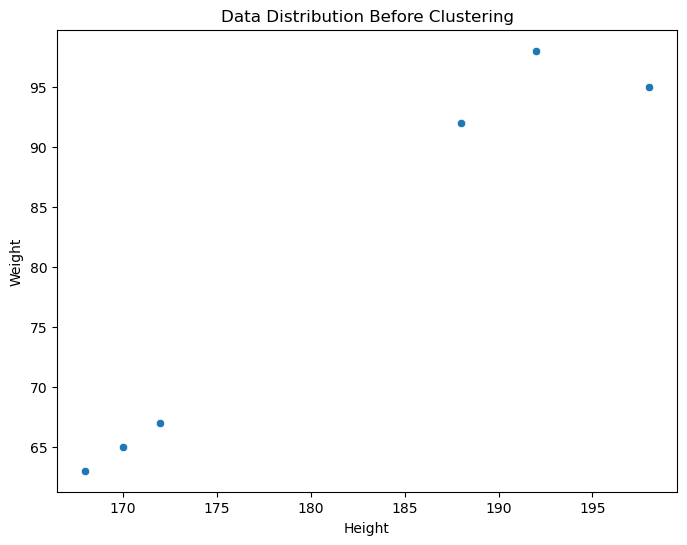

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='Height', y='Weight')
plt.title('Data Distribution Before Clustering')
plt.show()

In [16]:
from sklearn.preprocessing import StandardScaler

x = data[['Height', 'Weight']]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled

array([[-0.96398156, -0.99050727],
       [-0.79386717, -0.85843963],
       [-1.13409595, -1.12257491],
       [ 1.41761994,  0.99050727],
       [ 0.90727676,  1.18860872],
       [ 0.56704798,  0.79240582]])

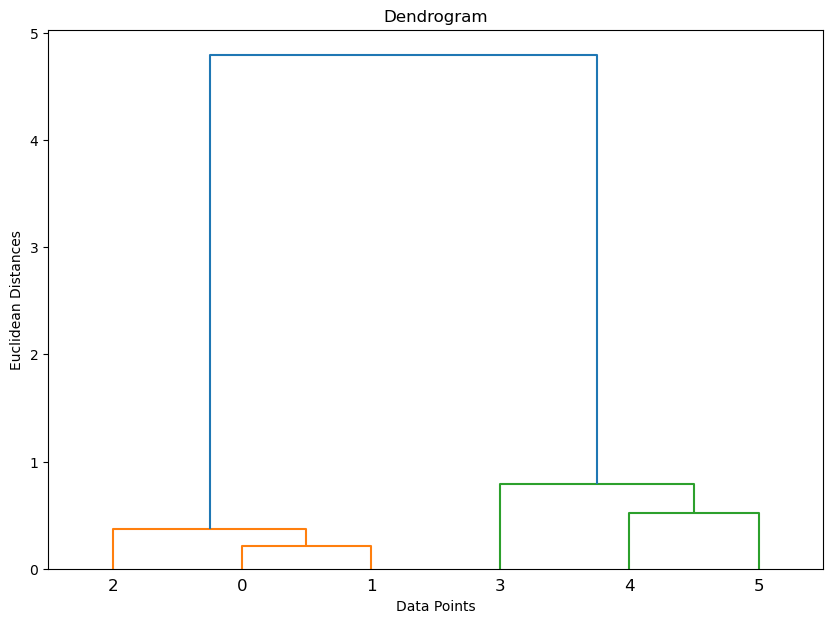

In [ ]:
import scipy.cluster.hierarchy as sch
plt.figure(figsize=(10, 7))
plt.title('Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distances')

dendrogram = sch.dendrogram(sch.linkage(x_scaled, method='ward'))
plt.show()

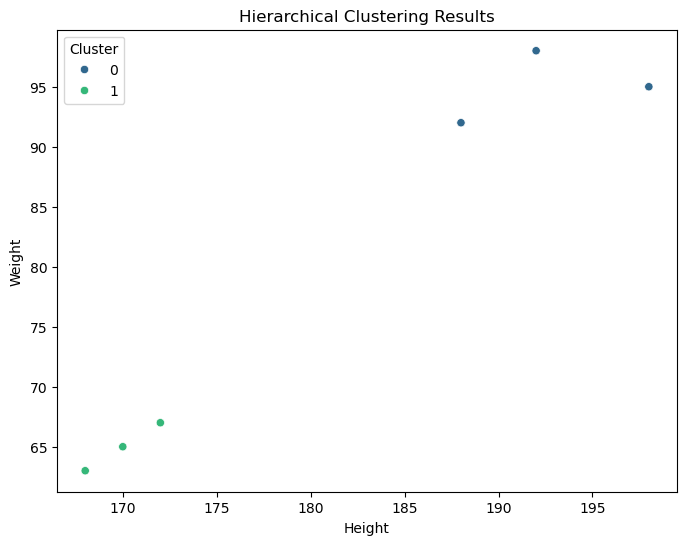

In [17]:
from sklearn.cluster import AgglomerativeClustering

hc_model = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')

cluster_labels = hc_model.fit_predict(x_scaled)

data['Cluster'] = cluster_labels

plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='Height', y='Weight', hue='Cluster', palette='viridis')
plt.title('Hierarchical Clustering Results')
plt.show()

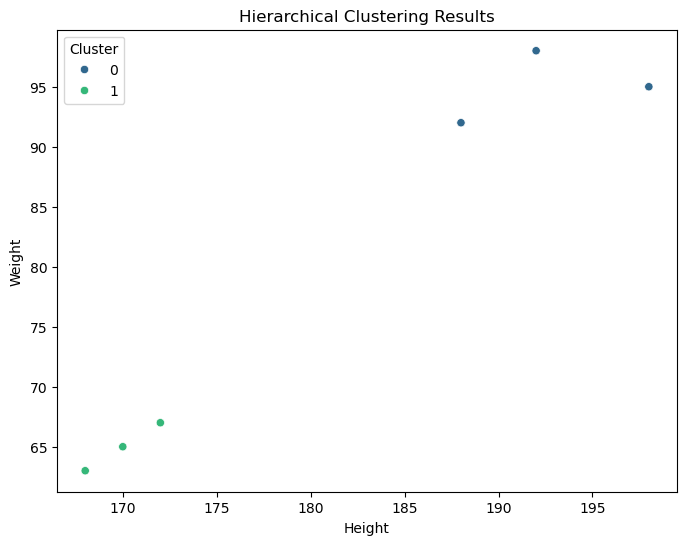

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='Height', y='Weight', hue='Cluster', palette='viridis')
plt.title('Hierarchical Clustering Results')
plt.show()

In [18]:
from sklearn.metrics import silhouette_score
silhouette_avg = silhouette_score(x_scaled, cluster_labels)
print(f'Silhouette Score: {silhouette_avg:.2f}')

Silhouette Score: 0.83
